# 03 - Evaluasi & Interpretasi Model
**Capstone Project - Machine Learning UAS**
Nama: Laily Muthia N | NIM: A11.2024.15618

CRISP-DM Tahap 5: **Evaluation**

In [13]:
import sys, os
os.chdir("..")
sys.path.append(os.path.join(os.getcwd(), "src"))
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
import shap
from data_preprocessing import run_pipeline
import warnings
warnings.filterwarnings("ignore")

data = run_pipeline(save=False)
X_test, y_test = data["X_test"], data["y_test"]

models = {
    "RandomForest": joblib.load("models/RandomForest.pkl"),
    "XGBoost": joblib.load("models/XGBoost.pkl"),
    "SVM": joblib.load("models/SVM.pkl"),
}
with open("models/best_model_name.txt") as f:
    best_name = f.read().strip()
best_model = joblib.load("models/best_model.pkl")
print("Model terbaik:", best_name)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/heart.csv'

## 1. Perbandingan Metrik Evaluasi (Test Set)
Metrik yang digunakan: **Accuracy, Precision, Recall, F1-Score, ROC-AUC**
(sesuai kebutuhan klasifikasi dengan class imbalance ringan).

In [ ]:
rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
metrics_df = pd.DataFrame(rows).sort_values("F1-Score", ascending=False)
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,XGBoost,0.913043,0.930000,0.911765,0.920792,0.947274
0,RandomForest,0.858696,0.858491,0.892157,0.875000,0.931851
2,SVM,0.853261,0.857143,0.882353,0.869565,0.932090


## 2. Confusion Matrix & ROC Curve

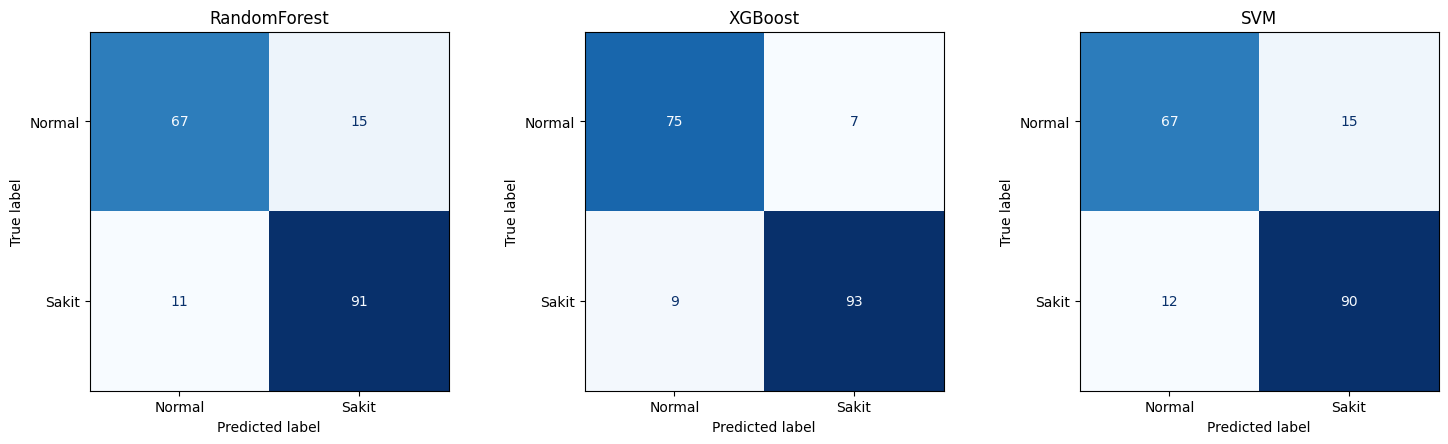

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4.5))
for ax,(name,model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Normal","Sakit"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

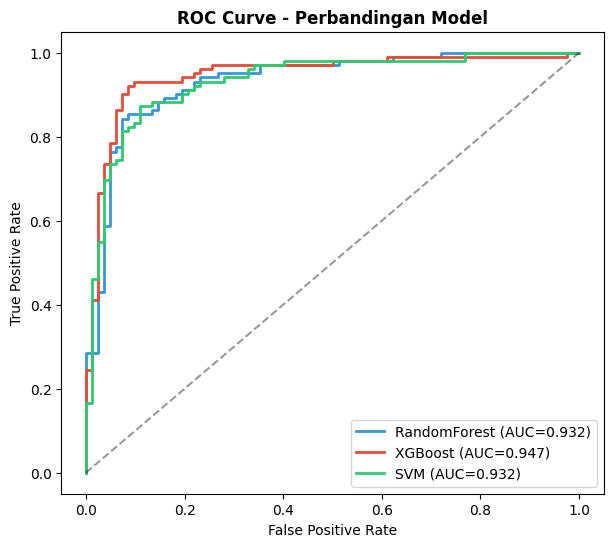

In [ ]:
fig, ax = plt.subplots(figsize=(7,6))
colors = {"RandomForest":"#3498db","XGBoost":"#e74c3c","SVM":"#2ecc71"}
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=colors[name], linewidth=2)
ax.plot([0,1],[0,1],"k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Perbandingan Model", fontweight="bold")
ax.legend(); plt.show()

## 3. Classification Report — Model Terbaik

In [ ]:
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=["Normal","Sakit"]))

              precision    recall  f1-score   support

      Normal       0.89      0.91      0.90        82
       Sakit       0.93      0.91      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184



## 4. Feature Importance & Interpretasi SHAP
Analisis *feature importance* dan **SHAP (SHapley Additive exPlanations)** digunakan untuk
memahami kontribusi tiap fitur terhadap prediksi model, sekaligus memberi interpretasi
yang bisa dipahami oleh stakeholder non-teknis (misalnya tenaga medis).

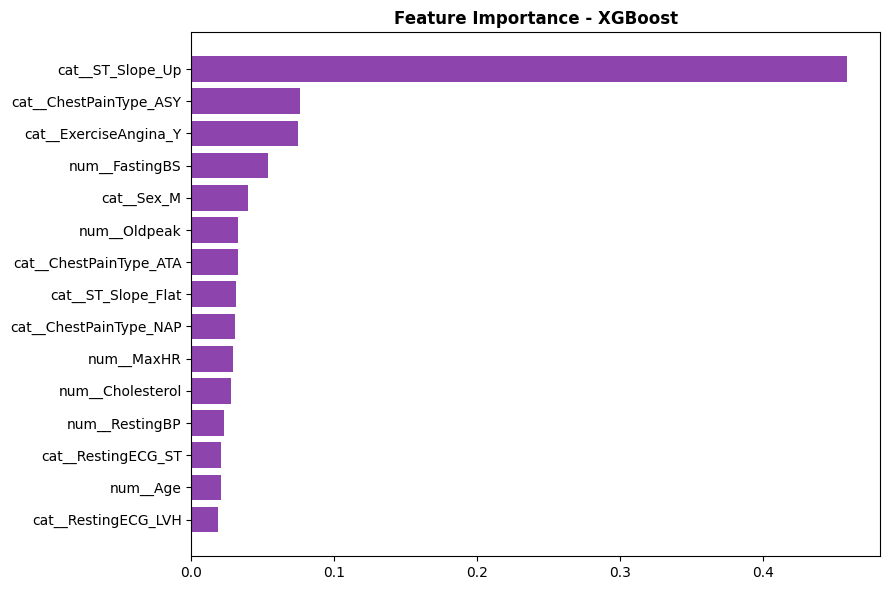

In [ ]:
prep = best_model.named_steps["prep"]
clf = best_model.named_steps["clf"]
feature_names = prep.get_feature_names_out()

if hasattr(clf, "feature_importances_"):
    imp_df = pd.DataFrame({"Feature": feature_names, "Importance": clf.feature_importances_})
    imp_df = imp_df.sort_values("Importance", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(9,6))
    ax.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1], color="#8e44ad")
    ax.set_title(f"Feature Importance - {best_name}", fontweight="bold")
    plt.tight_layout(); plt.show()

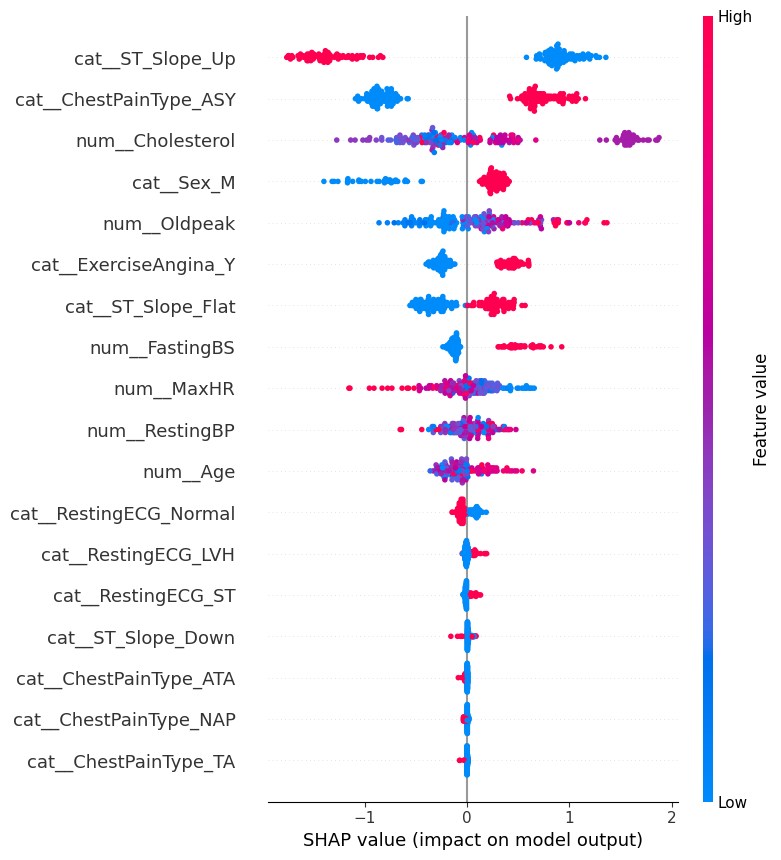

In [ ]:
X_test_transformed = prep.transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_df)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_df)

## 5. Kesimpulan Evaluasi

- Model **XGBoost** terpilih sebagai model terbaik dengan **F1-Score ≈ 0.91** dan **ROC-AUC ≈ 0.94**
  pada data test, mengungguli Random Forest dan SVM.
- Fitur **ST_Slope**, **ChestPainType (ASY)**, **Oldpeak**, dan **MaxHR** adalah kontributor
  utama terhadap prediksi, konsisten dengan pengetahuan medis mengenai indikator risiko kardiovaskular.
- Trade-off Precision–Recall pada kelas 'Sakit' menunjukkan model cukup andal untuk skrining awal,
  namun tetap perlu didampingi pemeriksaan klinis lanjutan (bukan pengganti diagnosis dokter).